In [59]:
import torch
print(torch.__version__)

2.13.0+cpu


In [60]:
# Step 2: Check Available Device
if torch.cuda.is_available():
 device = "cuda"
elif torch.backends.mps.is_available():
 device = "mps"
else:
 device = "cpu"
print(f'Using device ={device}')

Using device =cpu


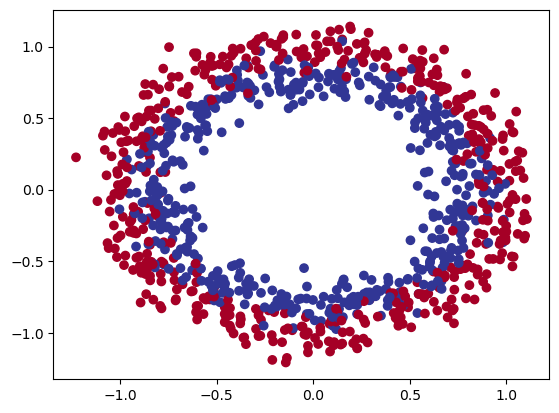

In [61]:
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
n_samples = 1000
X, y = make_circles(n_samples=n_samples, noise=0.090, random_state=42)
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu);

In [62]:
# Step 4: Convert to Tensors and Train-Test Split
from sklearn.model_selection import train_test_split
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [63]:
from torch import nn

class NeuralNetworkModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2,out_features=10)
        self.layer_2 = nn.Linear(in_features=10,out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

In [64]:
model = NeuralNetworkModel()
model.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802]])),
             ('layer_1.bias',
              tensor([-0.3258, -0.0829, -0.2872,  0.4691, -0.5582, -0.3260, -0.1997, -0.4252,
                       0.0667, -0.6984])),
             ('layer_2.weight',
              tensor([[ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
                        0.0346, -0.0997],
                      [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
                        0.1606, -0.1927],
                      [-0.3130, -0.1222, -0.2426,  0.2595,  0.0911,  0.1

In [65]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.05)

In [66]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct/len(y_true))*100
    return acc

In [67]:
epochs = 3000
train_loss_list = []

test_loss_list = []
torch.manual_seed(42)
# Cast the model and data to the device
model.to(device)
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)
for epoch in range(epochs):
    ### TRAINING
    model.train()
    # Forward Pass
    y_logits = model(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    # Compute Loss
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)
    # Optimizer Zero Grad
    optimizer.zero_grad()
    # Backpropagate
    loss.backward()
    # Step the optimizer
    optimizer.step()
    ### TESTING
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test).squeeze()
        test_preds = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_preds)
    train_loss_list.append(loss.item())
    test_loss_list.append(test_loss.item())
    if (epoch+1) % 100 == 0:
        print(f'Epoch {epoch+1}|Loss {loss:.5f}|Acc {acc:.2f}|TestLoss {test_loss:.5f}|Test Acc {test_acc:.2f}')

Epoch 100|Loss 0.69190|Acc 59.25|TestLoss 0.69227|Test Acc 63.00
Epoch 200|Loss 0.69127|Acc 52.50|TestLoss 0.69172|Test Acc 52.50
Epoch 300|Loss 0.69062|Acc 54.50|TestLoss 0.69115|Test Acc 53.00
Epoch 400|Loss 0.68984|Acc 53.87|TestLoss 0.69047|Test Acc 54.00
Epoch 500|Loss 0.68895|Acc 53.87|TestLoss 0.68967|Test Acc 54.00
Epoch 600|Loss 0.68791|Acc 53.87|TestLoss 0.68874|Test Acc 54.50
Epoch 700|Loss 0.68665|Acc 53.87|TestLoss 0.68761|Test Acc 53.50
Epoch 800|Loss 0.68513|Acc 54.62|TestLoss 0.68627|Test Acc 54.00
Epoch 900|Loss 0.68335|Acc 55.00|TestLoss 0.68470|Test Acc 54.50
Epoch 1000|Loss 0.68124|Acc 54.75|TestLoss 0.68289|Test Acc 55.50
Epoch 1100|Loss 0.67876|Acc 55.00|TestLoss 0.68084|Test Acc 55.50
Epoch 1200|Loss 0.67586|Acc 56.00|TestLoss 0.67846|Test Acc 56.50
Epoch 1300|Loss 0.67242|Acc 57.50|TestLoss 0.67569|Test Acc 56.00
Epoch 1400|Loss 0.66817|Acc 59.25|TestLoss 0.67227|Test Acc 58.50
Epoch 1500|Loss 0.66291|Acc 61.25|TestLoss 0.66819|Test Acc 61.00
Epoch 1600|Loss 0.6

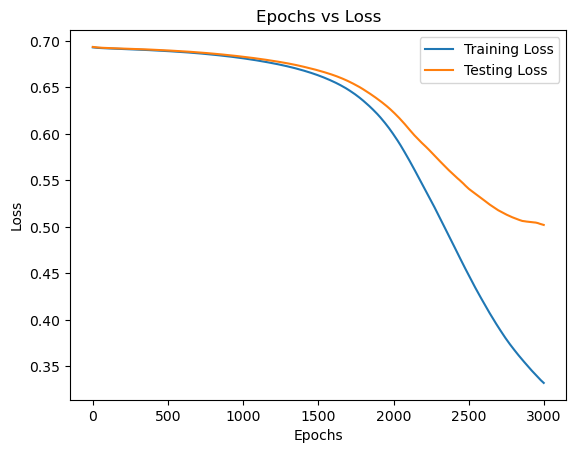

In [68]:
#Plot Loss Curves
plt.plot(range(epochs), train_loss_list, label="Training Loss")
plt.plot(range(epochs), test_loss_list, label="Testing Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Epochs vs Loss");

In [69]:
from helper_functions import plot_decision_boundary

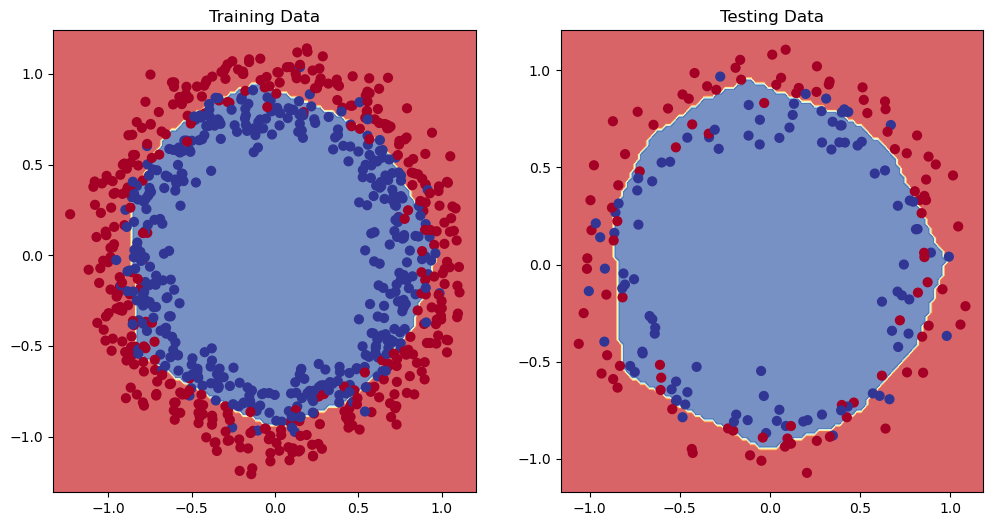

In [70]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Training Data")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Testing Data")
plot_decision_boundary(model, X_test, y_test)

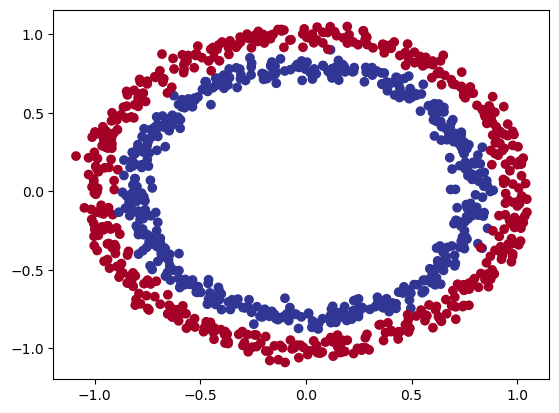

In [71]:
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
n_samples = 1000
X, y = make_circles(n_samples=n_samples, noise=0.04, random_state=42)
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu);